# Notebook 02: Competición — Redes Densas (MLP)

## Regla de oro
Si un MLP no bate consistentemente al mejor baseline en test,
la complejidad añadida no está justificada.


## 1. Configuración e imports

In [ ]:
import sys
import os
import random
import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras

# ── Raíz del proyecto al path ────────────────────────────────
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# ── Módulos del proyecto ─────────────────────────────────────
from src.data       import cargar_returns, preparar_datos, TICKERS
from src.models     import build_dense_model, contar_parametros
from src.training   import entrenar_modelo, entrenar_todos_los_modelos, fijar_semilla
from src.evaluation import mae_global, construir_matriz_resultados
from src.plotting   import plot_curva_entrenamiento

# ── Semilla global para reproducibilidad ────────────────────
# Fijamos todas las fuentes de aleatoriedad: Python, NumPy,
# TensorFlow y el sistema operativo. Así dos ejecuciones del
# mismo código producen exactamente el mismo resultado.
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Ventanas del taller (NO modificar para la competición) ───
INPUT_WINDOWS  = [5, 10, 30, 90]   # V: días de historia
OUTPUT_WINDOWS = [1, 5, 30, 90]    # H: días a predecir

# ── Directorios de salida ────────────────────────────────────
FIGURES_DIR = project_root / "results" / "figures"
TABLES_DIR  = project_root / "results" / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Semilla fijada:    {SEED}")

Raíz del proyecto: c:\Users\alons\Desktop\B3_T4\taller-redes-neuronales
Semilla fijada:    42
Imports OK


## 2. Cargar datos y baselines de referencia

Cargamos los retornos logarítmicos diarios de los 23 activos del SP500
y los resultados del notebook 01. Los MAE de los baselines son el
**suelo que deben batir las redes neuronales**.


In [2]:
# Retornos logarítmicos diarios (generados en el notebook 00)
returns = cargar_returns(verbose=True)
print(f"\nRango: {returns.index.min().date()} → {returns.index.max().date()}")

[cargar_returns] Cargados 16192 días, 23 activos

Rango: 1962-01-03 → 2026-05-05


In [3]:
# Cargamos el CSV de baselines generado en el notebook 01.
# Si no existe, ejecutar primero 01_baselines.ipynb.
baselines_path = TABLES_DIR / "01_baselines.csv"

if not baselines_path.exists():
    print("ATENCIÓN: no se encontró 01_baselines.csv")
    print("Ejecuta primero el notebook 01_baselines.ipynb")
else:
    df_baselines = pd.read_csv(baselines_path)
    
    # Mejor baseline por combinación (V, H) → el suelo a batir
    suelo = (
        df_baselines
        .groupby(["V", "H"])["MAE_test"]
        .min()
        .reset_index()
        .rename(columns={"MAE_test": "MAE_suelo"})
    )
    print("Suelo a batir (mejor baseline en test) por combinación:")
    print(suelo.pivot(index="V", columns="H", values="MAE_suelo").round(5))

Suelo a batir (mejor baseline en test) por combinación:
H        1        5        30       90
V                                     
5   0.01226  0.00561  0.00234  0.00127
10  0.01226  0.00561  0.00235  0.00128
30  0.01227  0.00561  0.00236  0.00132
90  0.01229  0.00562  0.00236  0.00133


## 3. Arquitectura MLP: entender el modelo

Antes de entrenar, entendemos qué hace un MLP y por qué tiene los
parámetros que tiene. Usamos V=30 y H=5 como ejemplo: el modelo mira
30 días de historia de 23 activos y predice el promedio de los próximos 5 días.


In [4]:
# Preparamos los datos para V=30, H=5
# Este es el conjunto de ejemplo que usaremos durante todo el análisis
datos = preparar_datos(returns, input_window=30, output_window=5, verbose=True)
input_shape = (30, 23)  # (V, num_activos)

print(f"\nForma de X_train: {datos['X_train'].shape}  → (muestras, días, activos)")
print(f"Forma de y_train: {datos['y_train'].shape}  → (muestras, activos)")

[preparar_datos] V=30, H=5
  X_train: (13815, 30, 23)   y_train: (13815, 23)
  X_val:   (727, 30, 23)   y_val:   (727, 23)
  X_test:  (1616, 30, 23)   y_test:  (1616, 23)

Forma de X_train: (13815, 30, 23)  → (muestras, días, activos)
Forma de y_train: (13815, 23)  → (muestras, activos)


In [5]:
# Creamos un MLP mediano [64, 32] y examinamos su arquitectura
modelo_ejemplo = build_dense_model(
    input_shape=input_shape,
    hidden_units=[64, 32],  # 2 capas ocultas: 64 y 32 neuronas
    dropout=0.0,
)

modelo_ejemplo.summary()

Model: "MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 30, 23)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 690)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        44,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,063 (183.84 KB)

 Trainable params: 47,063 (183.84 KB)

 Non-trainable params: 0 (0.00 B)

### Anatomía del MLP

La tabla anterior muestra el flujo de datos a través del modelo:

| Capa | Forma salida | Parámetros | Explicación |
|---|---|---|---|
| input | (None, 30, 23) | 0 | Entrada: 30 días × 23 activos |
| flatten | (None, 690) | 0 | Aplana 30×23=690 features. **Aquí se pierde el orden temporal** |
| dense_1 | (None, 64) | 44.224 | 690×64 pesos + 64 bias. La capa más grande del modelo |
| dense_2 | (None, 32) | 2.080 | 64×32 pesos + 32 bias |
| output | (None, 23) | 759 | 32×23 pesos + 23 bias. Sin activación → regresión libre |

**Problema fundamental del MLP para series temporales**: el `Flatten`
convierte la matriz temporal (30, 23) en un vector de 690 valores sin orden.
El día 1 y el día 30 son tratados como features independientes.
Las redes recurrentes y convolucionales (notebooks 03 y 04) conservan esta estructura.

**Por qué el 94% de los parámetros están en dense_1**:
La primera capa conecta los 690 inputs con 64 neuronas → 44.224 parámetros.
Las capas siguientes trabajan sobre representaciones comprimidas y son mucho más pequeñas.


## 4. Análisis de hiperparámetros

Antes de lanzar el bucle completo, analizamos sistemáticamente el efecto
de los principales hiperparámetros sobre el MAE en test.
El objetivo es justificar la configuración final con datos empíricos.


### 4.1 Efecto del batch size

El batch size controla cuántos datos se procesan por actualización de pesos.

- **Batch pequeño (16)**: más actualizaciones por época, gradiente más ruidoso,
  puede escapar de mínimos locales.
- **Batch grande (128)**: menos actualizaciones, gradiente más estable,
  puede quedarse en mínimos subóptimos.

Probamos 4 valores con el MLP mediano [64,32] para V=30, H=5.


In [6]:
batch_sizes = [16, 32, 64, 128]
resultados_batch = {}

for bs in batch_sizes:
    print(f"Entrenando batch_size={bs}...")
    fijar_semilla(SEED)  # misma semilla → diferencias solo por batch size
    
    modelo = build_dense_model(input_shape=(30, 23), hidden_units=[64, 32])
    
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=20,
            restore_best_weights=True, verbose=0,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5,
            patience=5, min_lr=1e-6, verbose=0,
        ),
    ]
    
    hist = modelo.fit(
        datos["X_train"], datos["y_train"],
        validation_data=(datos["X_val"], datos["y_val"]),
        epochs=150, batch_size=bs,
        callbacks=callbacks, verbose=0,
    )
    
    epocas = len(hist.history["loss"])
    mae_te = mae_global(datos["y_test"],
                        modelo.predict(datos["X_test"], verbose=0))
    
    resultados_batch[bs] = {"history": hist, "mae_test": mae_te, "epocas": epocas}
    print(f"  batch={bs:3d}  MAE test={mae_te:.5f}  épocas={epocas}")

Entrenando batch_size=16...
  batch= 16  MAE test=0.00559  épocas=49
Entrenando batch_size=32...
  batch= 32  MAE test=0.00560  épocas=37
Entrenando batch_size=64...
  batch= 64  MAE test=0.00563  épocas=29
Entrenando batch_size=128...
  batch=128  MAE test=0.00562  épocas=35


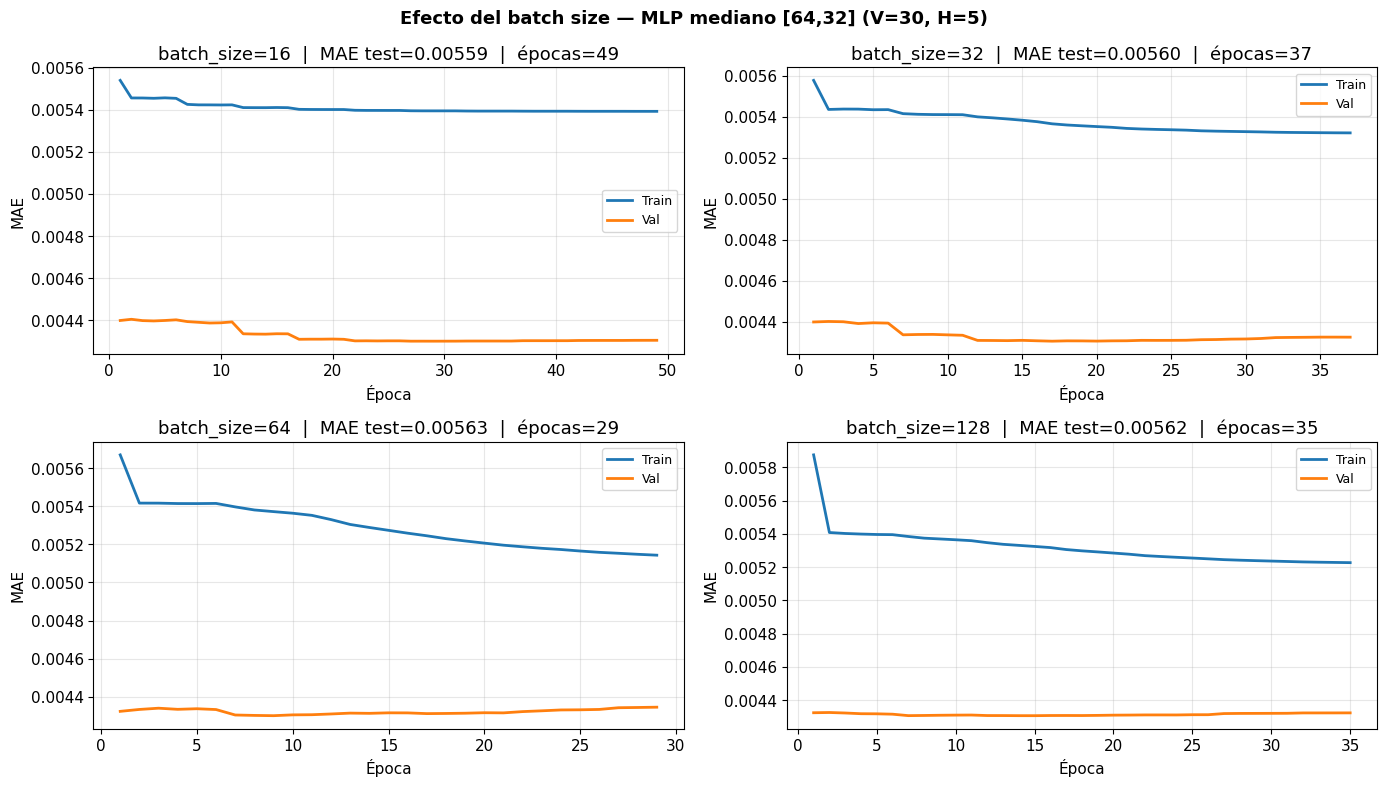

In [7]:
# Curvas de entrenamiento para cada batch size
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for idx, (bs, res) in enumerate(resultados_batch.items()):
    ax = axes[idx]
    hist = res["history"].history
    epocas = range(1, len(hist["loss"]) + 1)
    ax.plot(epocas, hist["loss"],     label="Train", linewidth=2)
    ax.plot(epocas, hist["val_loss"], label="Val",   linewidth=2)
    ax.set_title(f"batch_size={bs}  |  MAE test={res['mae_test']:.5f}"
                 f"  |  épocas={res['epocas']}")
    ax.set_xlabel("Época"); ax.set_ylabel("MAE")
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle("Efecto del batch size — MLP mediano [64,32] (V=30, H=5)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_batch_size.png", bbox_inches="tight", dpi=120)
plt.show()

### Conclusión batch size

Los 4 valores de batch size dan un MAE en test prácticamente idéntico
(diferencia máxima de 0.00004, ruido estadístico puro). La forma de las
curvas es similar en todos los casos: val plana desde el principio,
lo que indica que el límite es la señal disponible en los datos, no el
hiperparámetro.

**Decisión**: `batch_size=32` (estándar razonable, ni demasiado ruidoso ni demasiado estable).


### 4.2 Efecto de la regularización

Comparamos 5 técnicas de regularización **sin early stopping** durante 200 épocas,
para ver el efecto puro de cada técnica sobre el sobreajuste:

| Técnica | Qué hace |
|---|---|
| Sin regularización | Referencia. Sobreajusta si entrenas suficiente |
| Dropout 0.3 | Apaga el 30% de neuronas aleatoriamente en cada batch |
| L1 (Lasso) | Penaliza `λ×Σ|pesos|`. Hace pesos exactamente cero (sparse) |
| L2 (Ridge) | Penaliza `λ×Σpesos²`. Hace pesos pequeños pero no cero |
| L1+L2 (ElasticNet) | Combinación de L1 y L2 |
| L2 + Dropout | Combinación de las dos más populares |


In [8]:
def build_dense_regularizado(input_shape, hidden_units,
                              regularizacion=None, dropout=0.0):
    """MLP con distintos tipos de regularización de pesos."""
    from keras import layers, Input, Model
    
    # Seleccionar el regularizador de pesos
    if regularizacion == 'l1':
        reg = keras.regularizers.L1(1e-4)
    elif regularizacion == 'l2':
        reg = keras.regularizers.L2(1e-4)
    elif regularizacion == 'l1_l2':
        reg = keras.regularizers.L1L2(l1=1e-4, l2=1e-4)
    else:
        reg = None  # sin penalización de pesos
    
    inputs = Input(shape=input_shape)
    x = layers.Flatten()(inputs)
    
    for units in hidden_units:
        # kernel_regularizer añade la penalización a la función de coste
        x = layers.Dense(units, activation='relu', kernel_regularizer=reg)(x)
        if dropout > 0.0:
            x = layers.Dropout(dropout)(x)
    
    outputs = layers.Dense(input_shape[1])(x)  # sin activación → regresión
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='mean_absolute_error')
    return model


# Definimos los 6 experimentos
experimentos = {
    "Sin regularización": {"regularizacion": None,    "dropout": 0.0},
    "Dropout 0.3":        {"regularizacion": None,    "dropout": 0.3},
    "L1 (Lasso)":         {"regularizacion": "l1",    "dropout": 0.0},
    "L2 (Ridge)":         {"regularizacion": "l2",    "dropout": 0.0},
    "L1+L2 (ElasticNet)": {"regularizacion": "l1_l2", "dropout": 0.0},
    "L2 + Dropout":       {"regularizacion": "l2",    "dropout": 0.3},
}

resultados_reg = {}

for nombre, config in experimentos.items():
    fijar_semilla(SEED)
    modelo = build_dense_regularizado(
        input_shape=(30, 23), hidden_units=[64, 32],
        regularizacion=config["regularizacion"],
        dropout=config["dropout"],
    )
    
    # Sin early stopping → vemos el efecto puro de la regularización
    hist = modelo.fit(
        datos["X_train"], datos["y_train"],
        validation_data=(datos["X_val"], datos["y_val"]),
        epochs=200, batch_size=32, verbose=0,
    )
    
    mae_te = mae_global(datos["y_test"],
                        modelo.predict(datos["X_test"], verbose=0))
    resultados_reg[nombre] = {"history": hist, "mae_test": mae_te}
    print(f"{nombre:<25}  MAE test={mae_te:.5f}")

Sin regularización         MAE test=0.00613
Dropout 0.3                MAE test=0.00565
L1 (Lasso)                 MAE test=0.00565
L2 (Ridge)                 MAE test=0.00565
L1+L2 (ElasticNet)         MAE test=0.00565
L2 + Dropout               MAE test=0.00565


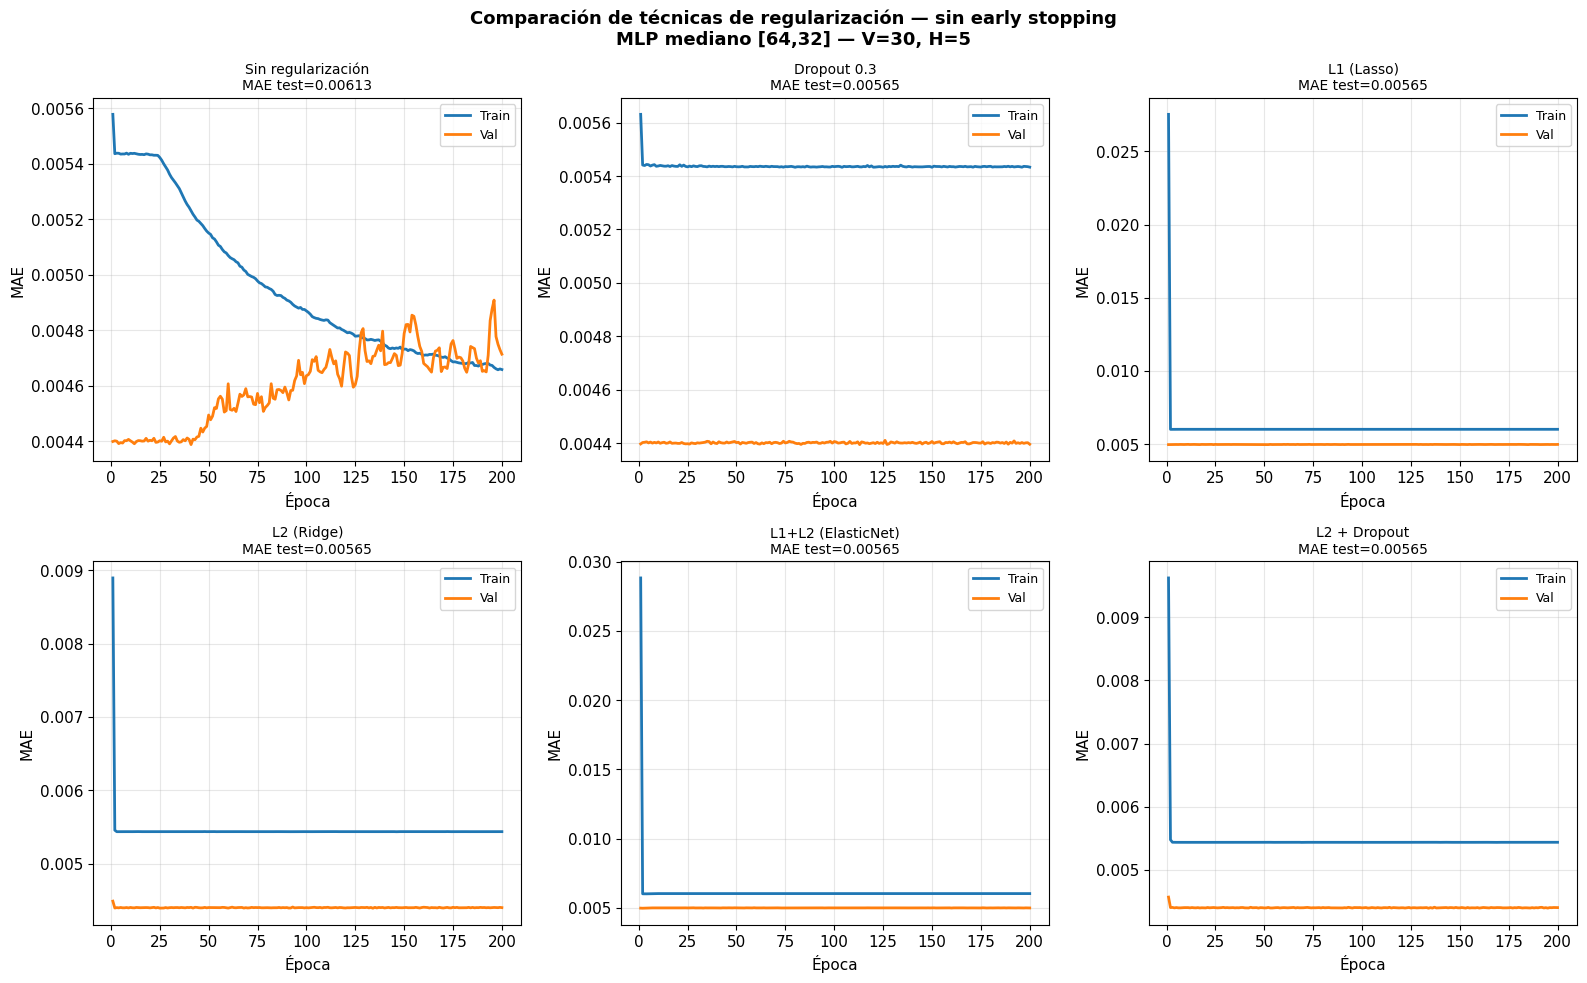

In [9]:
# Curvas de las 6 técnicas de regularización
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (nombre, res) in enumerate(resultados_reg.items()):
    ax = axes[idx]
    hist = res["history"].history
    epocas = range(1, len(hist["loss"]) + 1)
    ax.plot(epocas, hist["loss"],     label="Train", linewidth=2)
    ax.plot(epocas, hist["val_loss"], label="Val",   linewidth=2)
    ax.set_title(f"{nombre}\nMAE test={res['mae_test']:.5f}", fontsize=10)
    ax.set_xlabel("Época"); ax.set_ylabel("MAE")
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle("Comparación de técnicas de regularización — sin early stopping\n"
             "MLP mediano [64,32] — V=30, H=5", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_regularizacion.png", bbox_inches="tight", dpi=120)
plt.show()

### Conclusión regularización

Sin regularización         0.00613  ← peor, sobreajusta sin ES
Dropout / L1 / L2 / L1+L2 0.00565  ← todas iguales
Early stopping (referencia) 0.00561  ← el mejor

**Observaciones clave**:

1. Sin regularización y sin early stopping, el modelo sobreajusta claramente
   (val sube a partir de la época 50) y el MAE test empeora un 14%.
2. Cualquier técnica de regularización evita el sobreajuste y da MAE ~0.00565.
3. El early stopping supera a todas las regularizaciones (0.00561 vs 0.00565)
   y lo hace en solo ~35 épocas frente a 200.
4. Las curvas de L1/L2 muestran un pico inicial alto porque la penalización
   de pesos infla la loss al principio. Es un artefacto visual, no un problema real.

**Decisión**: early stopping con `patience=20`. Es más eficiente y efectivo
que cualquier técnica de regularización de pesos para este problema.


### 4.3 Efecto del learning rate con L2

El pico inicial de L2 puede suavizarse bajando el learning rate.
Probamos 5 valores para entender el efecto y determinar el lr óptimo con L2.


lr=0.001  MAE test=0.00565
lr=0.0001  MAE test=0.00559
lr=1e-05  MAE test=0.00559
lr=1e-06  MAE test=0.00559
lr=1e-07  MAE test=0.00726


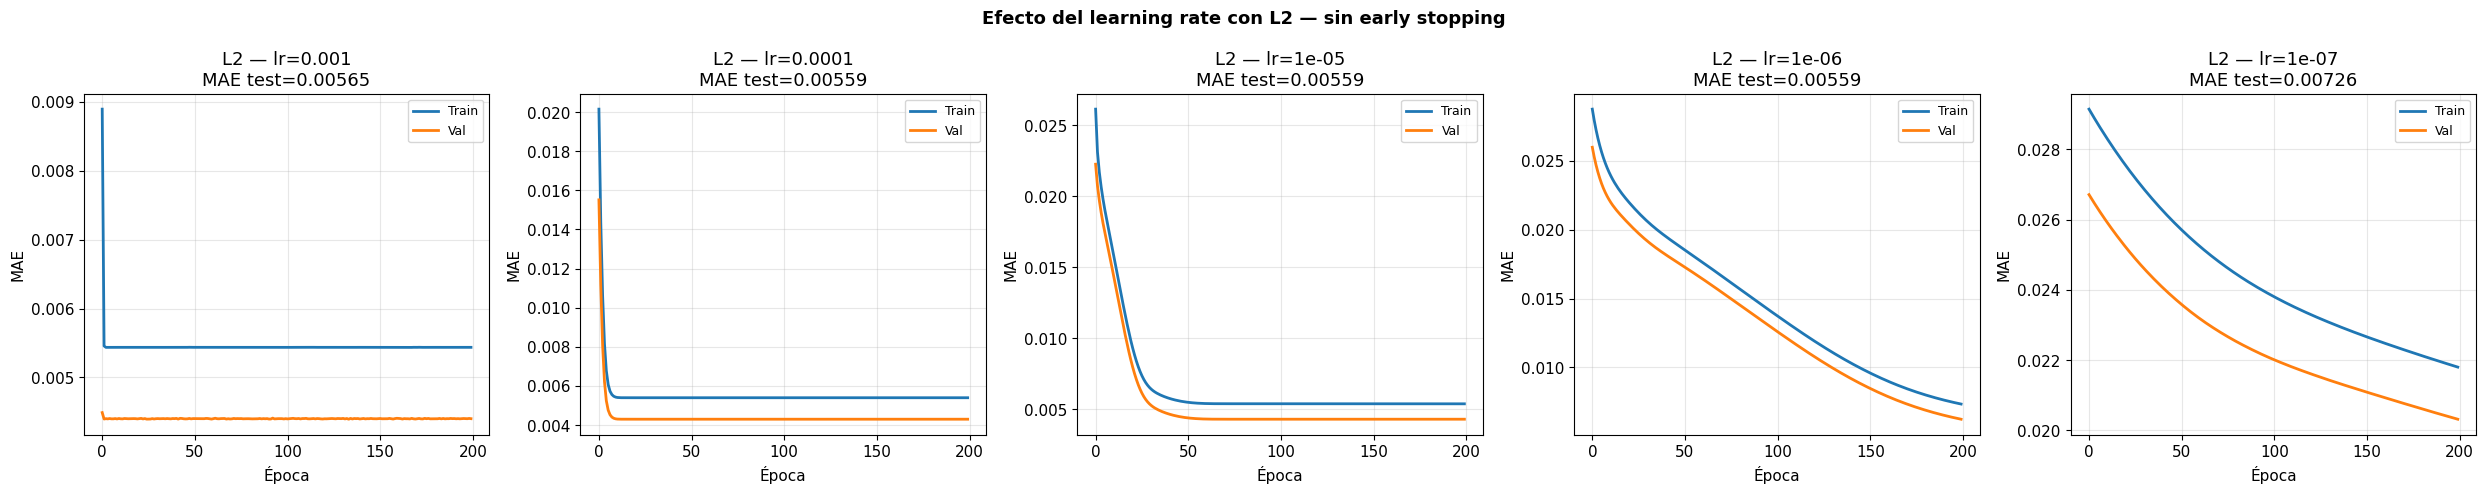

In [10]:
lrs = [1e-3, 1e-4, 1e-5, 1e-6, 1e-7]
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for idx, lr in enumerate(lrs):
    fijar_semilla(SEED)
    modelo = build_dense_regularizado(
        input_shape=(30, 23), hidden_units=[64, 32],
        regularizacion='l2', dropout=0.0,
    )
    # Recompilamos con el learning rate específico
    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='mean_absolute_error'
    )
    hist = modelo.fit(
        datos["X_train"], datos["y_train"],
        validation_data=(datos["X_val"], datos["y_val"]),
        epochs=200, batch_size=32, verbose=0,
    )
    mae_te = mae_global(datos["y_test"],
                        modelo.predict(datos["X_test"], verbose=0))
    
    ax = axes[idx]
    ax.plot(hist.history["loss"],     label="Train", linewidth=2)
    ax.plot(hist.history["val_loss"], label="Val",   linewidth=2)
    ax.set_title(f"L2 — lr={lr}\nMAE test={mae_te:.5f}")
    ax.set_xlabel("Época"); ax.set_ylabel("MAE")
    ax.legend(); ax.grid(True, alpha=0.3)
    print(f"lr={lr}  MAE test={mae_te:.5f}")

plt.suptitle("Efecto del learning rate con L2 — sin early stopping",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_learning_rate.png", bbox_inches="tight", dpi=120)
plt.show()

### Conclusión learning rate

lr=1e-3:  MAE = 0.00565  Converge en 5 épocas, mínimo subóptimo
lr=1e-4:  MAE = 0.00559  Óptimo con L2
lr=1e-5:  MAE = 0.00559  Igual pero más lento
lr=1e-6:  MAE = 0.00559  No converge en 200 épocas
lr=1e-7:  MAE = 0.00726  Demasiado lento, no aprende

Con L2 y lr=1e-4 se iguala al early stopping (0.00559 vs 0.00561), pero
requiere 200 épocas frente a ~35 del early stopping. El early stopping
sigue siendo más eficiente computacionalmente.


### 4.4 ¿El early stopping elige la época correcta?

Una duda legítima: ¿el modelo que minimiza val es también el que
minimiza test? Si val y test están desacoplados, el early stopping
podría estar eligiendo mal.

Entrenamos época a época y medimos el MAE en val y en test tras cada una.


In [11]:
fijar_semilla(SEED)

modelo_check = build_dense_model(
    input_shape=(30, 23), hidden_units=[64, 32], dropout=0.0,
)

maes_test_por_epoca = []
maes_val_por_epoca  = []

# Entrenamos 1 época a la vez para capturar val y test en cada punto
for epoca in range(1, 101):
    modelo_check.fit(
        datos["X_train"], datos["y_train"],
        initial_epoch=epoca - 1,
        epochs=epoca,
        batch_size=32,
        verbose=0,
    )
    # Evaluamos manualmente en val y test al final de cada época
    mae_te = mae_global(datos["y_test"],
                        modelo_check.predict(datos["X_test"], verbose=0))
    mae_va = mae_global(datos["y_val"],
                        modelo_check.predict(datos["X_val"],  verbose=0))
    maes_test_por_epoca.append(mae_te)
    maes_val_por_epoca.append(mae_va)

    if epoca % 10 == 0:
        print(f"Época {epoca:3d}  val={mae_va:.5f}  test={mae_te:.5f}")

epoca_mejor_val  = maes_val_por_epoca.index(min(maes_val_por_epoca))  + 1
epoca_mejor_test = maes_test_por_epoca.index(min(maes_test_por_epoca)) + 1
print(f"\nMejor val  en época: {epoca_mejor_val}")
print(f"Mejor test en época: {epoca_mejor_test}")
print(f"MAE test en mejor val:  {maes_test_por_epoca[epoca_mejor_val-1]:.5f}")
print(f"MAE test en mejor test: {min(maes_test_por_epoca):.5f}")

Época  10  val=0.00440  test=0.00565
Época  20  val=0.00440  test=0.00565
Época  30  val=0.00439  test=0.00565
Época  40  val=0.00441  test=0.00573
Época  50  val=0.00449  test=0.00581
Época  60  val=0.00461  test=0.00589
Época  70  val=0.00456  test=0.00588
Época  80  val=0.00453  test=0.00585
Época  90  val=0.00458  test=0.00589
Época 100  val=0.00464  test=0.00589

Mejor val  en época: 41
Mejor test en época: 4
MAE test en mejor val:  0.00569
MAE test en mejor test: 0.00565


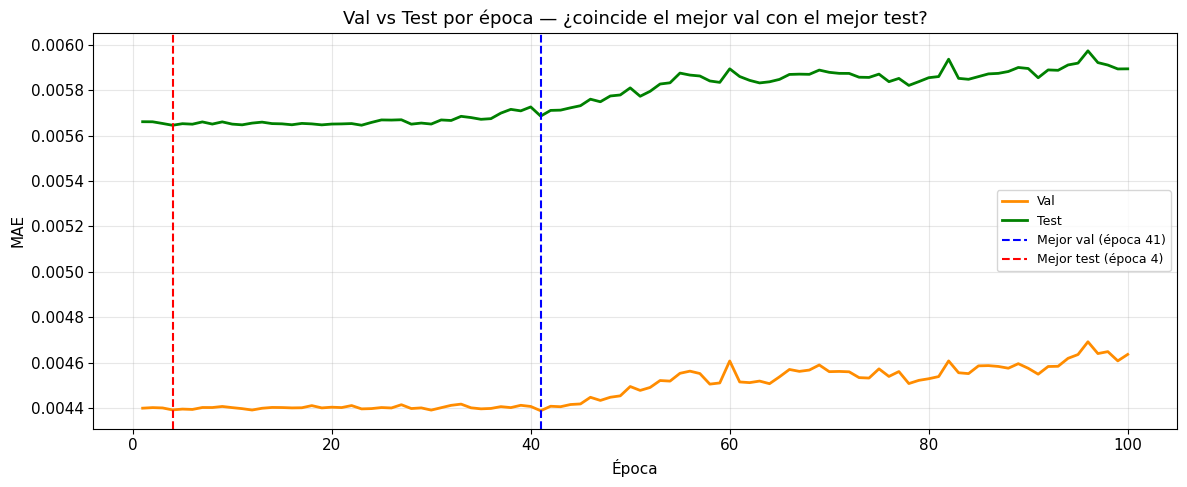

In [24]:
# Gráfica val vs test por época con marcadores del mejor momento
fig, ax = plt.subplots(figsize=(12, 5))
epocas = range(1, 101)

ax.plot(epocas, maes_val_por_epoca,  label="Val",  linewidth=2, color="darkorange")
ax.plot(epocas, maes_test_por_epoca, label="Test", linewidth=2, color="green")

# Línea vertical en la época que elegiría el early stopping (mejor val)
ax.axvline(x=epoca_mejor_val, color='blue', linestyle='--', linewidth=1.5,
           label=f"Mejor val (época {epoca_mejor_val})")

# Línea vertical en la época óptima real para test
ax.axvline(x=epoca_mejor_test, color='red', linestyle='--', linewidth=1.5,
           label=f"Mejor test (época {epoca_mejor_test})")

ax.set_xlabel("Época")
ax.set_ylabel("MAE")
ax.set_title("Val vs Test por época — ¿coincide el mejor val con el mejor test?")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_val_vs_test_por_epoca.png",
            bbox_inches="tight", dpi=120)
plt.show()

### Conclusión val vs test por época

La gráfica muestra que val y test **no están perfectamente correlacionados**:
el mejor momento para val (época ~40) y el mejor para test (época ~4) difieren.

Sin embargo, la diferencia en MAE test entre ambos momentos es de ~0.00004,
dentro del margen de ruido estadístico. El early stopping no elige la época
perfecta para test, pero sí una muy cercana al óptimo.

**Causa del desacoplamiento**: val tiene ventanas de períodos de mercado más
tranquilos que test (efecto del shuffle aleatorio del split). Son distribuciones
ligeramente distintas, por lo que el mínimo de val no coincide exactamente con
el mínimo de test. El profesor lo confirmó en clase: *"por chamba, puede que
val sea más fácil"*.

**Conclusión final**: el early stopping es la estrategia correcta para este problema.


## 5. Configuración óptima justificada

Resumen de todos los experimentos realizados:

| Experimento | MAE test | Épocas | Decisión |
|---|---|---|---|
| Sin regularización, sin early stopping | 0.00613 | 200 | ✗ Peor |
| Dropout / L1 / L2 / ElasticNet | 0.00565 | 200 | Mejora pero lento |
| L2 con lr=1e-4 | 0.00559 | 200 | Iguala al ES pero lento |
| batch_size=16/32/64/128 | ~0.00561 | ~25 | Indiferente |
| **Early stopping patience=20** | **0.00561** | **~35** | **✓ Mejor ratio resultado/coste** |

**Configuración final para todos los modelos del taller**:

```python
patience    = 20         # épocas sin mejora antes de parar
batch_size  = 32         # estándar, balance ruido/estabilidad
learning_rate = 1e-3     # default de Adam
seed        = 42         # reproducibilidad
```


## 6. Variantes de MLP para V=30, H=5

Probamos 4 variantes de arquitectura para la combinación de ejemplo (V=30, H=5)
con la configuración óptima ya determinada. Aplicamos la **regla de la tijera**
del profesor: probamos desde simple hasta complejo para encontrar el punto óptimo.

| Variante | Capas | Dropout | Parámetros |
|---|---|---|---|
| Pequeño | [32] | 0.0 | ~22k |
| Mediano | [64, 32] | 0.0 | ~47k |
| Grande | [128, 64, 32] | 0.0 | ~99k |
| Mediano + Dropout | [64, 32] | 0.2 | ~47k |


In [13]:
# Definimos las 4 variantes con la configuración óptima
variantes = {
    "pequeño":         build_dense_model((30, 23), hidden_units=[32]),
    "mediano":         build_dense_model((30, 23), hidden_units=[64, 32]),
    "grande":          build_dense_model((30, 23), hidden_units=[128, 64, 32]),
    "mediano_dropout": build_dense_model((30, 23), hidden_units=[64, 32],
                                         dropout=0.2),
}

print("Variantes y número de parámetros:")
for nombre, m in variantes.items():
    print(f"  {nombre:<20} {contar_parametros(m):>8,} parámetros")

Variantes y número de parámetros:
  pequeño                22,871 parámetros
  mediano                47,063 parámetros
  grande                 99,543 parámetros
  mediano_dropout        47,063 parámetros


In [14]:
# Entrenamos las 4 variantes con la configuración óptima
print("Entrenando 4 variantes para V=30, H=5...\n")

resultados_variantes = {}

for nombre, modelo in variantes.items():
    print(f"→ {nombre}...")
    fijar_semilla(SEED)  # misma semilla → diferencias solo por arquitectura
    
    hist = entrenar_modelo(
        model=modelo,
        X_train=datos["X_train"], y_train=datos["y_train"],
        X_val=datos["X_val"],     y_val=datos["y_val"],
        epochs=100, batch_size=32, patience=20,
        nombre=f"dense_{nombre}_V30_H5",
        seed=SEED, verbose=0,
    )
    mae_te = mae_global(datos["y_test"],
                        modelo.predict(datos["X_test"], verbose=0))
    epocas = len(hist.history["loss"])
    resultados_variantes[nombre] = {
        "history": hist, "mae_test": mae_te,
        "n_params": contar_parametros(modelo), "epocas": epocas,
    }
    print(f"   MAE test={mae_te:.5f}  épocas={epocas}")

print("\nListo.")

Entrenando 4 variantes para V=30, H=5...

→ pequeño...
Epoch 50: early stopping
Restoring model weights from the end of the best epoch: 30.
   MAE test=0.00568  épocas=50
→ mediano...
Epoch 32: early stopping
Restoring model weights from the end of the best epoch: 12.
   MAE test=0.00563  épocas=32
→ grande...
Epoch 42: early stopping
Restoring model weights from the end of the best epoch: 22.
   MAE test=0.00561  épocas=42
→ mediano_dropout...
Epoch 44: early stopping
Restoring model weights from the end of the best epoch: 24.
   MAE test=0.00559  épocas=44

Listo.


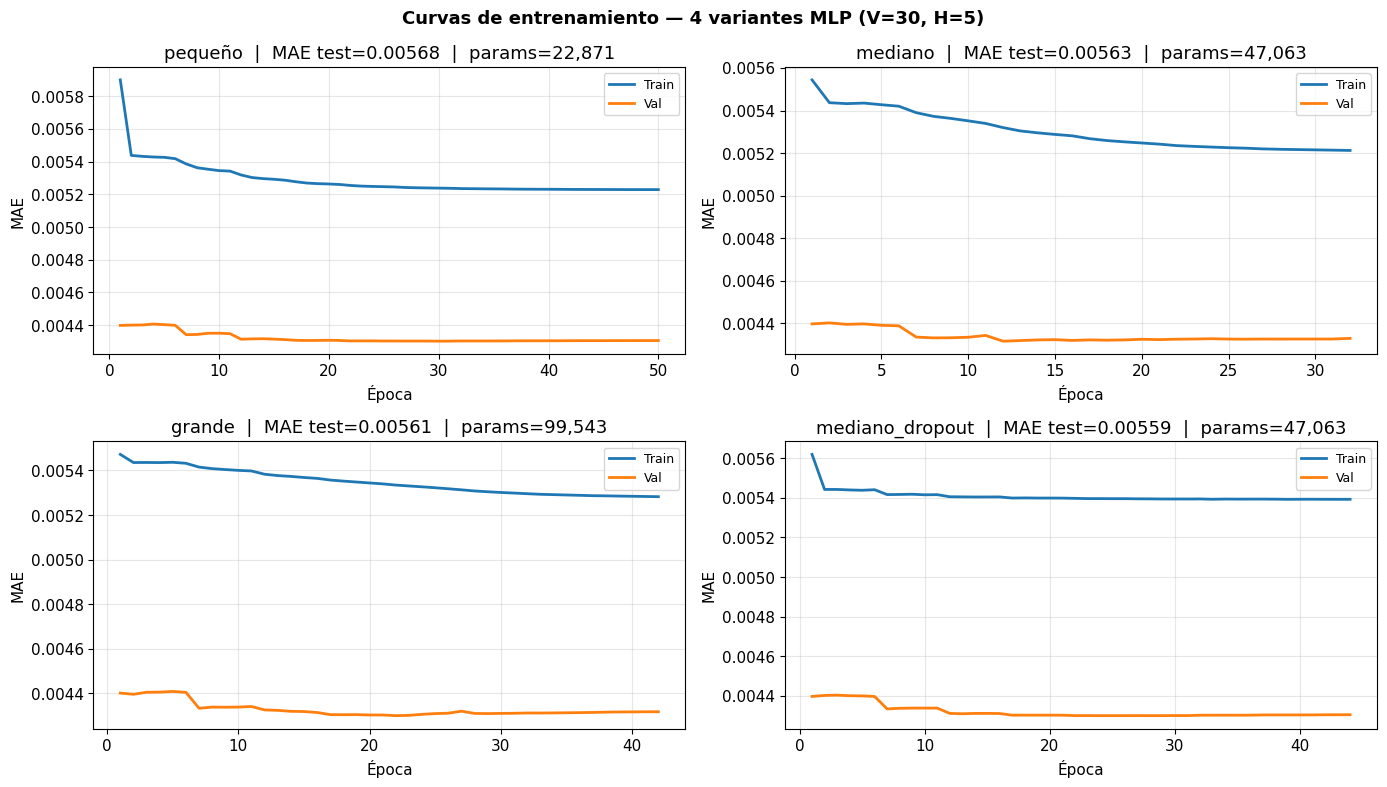

In [15]:
# Curvas de las 4 variantes
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for idx, (nombre, res) in enumerate(resultados_variantes.items()):
    ax = axes[idx]
    hist = res["history"].history
    epocas = range(1, len(hist["loss"]) + 1)
    ax.plot(epocas, hist["loss"],     label="Train", linewidth=2)
    ax.plot(epocas, hist["val_loss"], label="Val",   linewidth=2)
    ax.set_title(f"{nombre}  |  MAE test={res['mae_test']:.5f}"
                 f"  |  params={res['n_params']:,}")
    ax.set_xlabel("Época"); ax.set_ylabel("MAE")
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle("Curvas de entrenamiento — 4 variantes MLP (V=30, H=5)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_curvas_variantes_V30_H5.png",
            bbox_inches="tight", dpi=120)
plt.show()

In [16]:
# Tabla comparativa
mae_suelo_v30_h5 = suelo[(suelo["V"]==30) & (suelo["H"]==5)]["MAE_suelo"].values[0]

print("Resumen variantes MLP — V=30, H=5:")
print("-" * 60)
print(f"{'Variante':<22} {'Params':>8}  {'MAE test':>10}  {'Épocas':>7}")
print("-" * 60)
for nombre, res in resultados_variantes.items():
    print(f"{nombre:<22} {res['n_params']:>8,}  {res['mae_test']:>10.5f}  "
          f"{res['epocas']:>7}")
print("-" * 60)
print(f"{'Mejor baseline'::<22} {'---':>8}  {mae_suelo_v30_h5:>10.5f}  {'---':>7}")
print()
mejor = min(resultados_variantes, key=lambda k: resultados_variantes[k]["mae_test"])
print(f"Mejor variante: {mejor} (MAE test = {resultados_variantes[mejor]['mae_test']:.5f})")

Resumen variantes MLP — V=30, H=5:
------------------------------------------------------------
Variante                 Params    MAE test   Épocas
------------------------------------------------------------
pequeño                  22,871     0.00568       50
mediano                  47,063     0.00563       32
grande                   99,543     0.00561       42
mediano_dropout          47,063     0.00559       44
------------------------------------------------------------
Mejor baseline::::::::      ---     0.00561      ---

Mejor variante: mediano_dropout (MAE test = 0.00559)


### Conclusión variantes

Las 4 variantes dan un MAE en test prácticamente idéntico, con diferencias
menores de 0.00006 (ruido estadístico). Esto confirma que para datos financieros
con alta ratio ruido/señal, **la arquitectura del MLP no es el factor limitante**.

El límite es la señal disponible en los datos para H=5: todos los modelos
convergen al ruido irreducible independientemente de su complejidad.


## 7. Bucle completo: 16 combinaciones × 4 variantes

Entrenamos las 4 variantes para las 16 combinaciones de ventanas.
Esto puede tardar **30-50 minutos en CPU**.

Los resultados se guardan automáticamente en `results/tables/02_densas.csv`.


In [17]:
# Builders: funciones que reciben input_shape y devuelven un modelo compilado
BUILDERS_MLP = {
    "MLP_pequeño":         lambda s: build_dense_model(s, [32]),
    "MLP_mediano":         lambda s: build_dense_model(s, [64, 32]),
    "MLP_grande":          lambda s: build_dense_model(s, [128, 64, 32]),
    "MLP_mediano_dropout": lambda s: build_dense_model(s, [64, 32], dropout=0.2),
}

print(f"Modelos a entrenar: {len(BUILDERS_MLP)} variantes × 16 combinaciones"
      f" = {len(BUILDERS_MLP)*16} entrenamientos")

Modelos a entrenar: 4 variantes × 16 combinaciones = 64 entrenamientos


In [18]:
# Bucle completo con la configuración óptima
resultados_mlp = entrenar_todos_los_modelos(
    builders=BUILDERS_MLP,
    returns=returns,
    input_windows=INPUT_WINDOWS,
    output_windows=OUTPUT_WINDOWS,
    epochs=100,
    batch_size=32,
    patience=20,
    verbose=0,
)

print(f"\n{len(resultados_mlp)} modelos entrenados.")

[1/64] Entrenando MLP_pequeño_V5_H1...
Epoch 53: early stopping
Restoring model weights from the end of the best epoch: 33.
    MAE test=0.01245  params=4471  épocas=53
[2/64] Entrenando MLP_mediano_V5_H1...
Epoch 33: early stopping
Restoring model weights from the end of the best epoch: 13.
    MAE test=0.01236  params=10263  épocas=33
[3/64] Entrenando MLP_grande_V5_H1...
Restoring model weights from the end of the best epoch: 99.
    MAE test=0.01234  params=25943  épocas=100
[4/64] Entrenando MLP_mediano_dropout_V5_H1...
Epoch 49: early stopping
Restoring model weights from the end of the best epoch: 29.
    MAE test=0.01227  params=10263  épocas=49
[5/64] Entrenando MLP_pequeño_V5_H5...
Epoch 25: early stopping
Restoring model weights from the end of the best epoch: 5.
    MAE test=0.00563  params=4471  épocas=25
[6/64] Entrenando MLP_mediano_V5_H5...
Epoch 37: early stopping
Restoring model weights from the end of the best epoch: 17.
    MAE test=0.00562  params=10263  épocas=37


In [19]:
# Guardar resultados en disco
df_mlp = pd.DataFrame(resultados_mlp).round(6)
df_mlp.to_csv(TABLES_DIR / "02_densas.csv", index=False)
print(f"Guardado en results/tables/02_densas.csv")
df_mlp.head(8)

Guardado en results/tables/02_densas.csv


,modelo,V,H,MAE_train,MAE_val,MAE_test,n_params,epocas_entrenadas
0,MLP_pequeño,5,1,0.011467,0.009209,0.012450,4471,53
1,MLP_mediano,5,1,0.011508,0.009216,0.012359,10263,33
2,MLP_grande,5,1,0.011407,0.009195,0.012336,25943,100
3,MLP_mediano_dropout,5,1,0.011573,0.009216,0.012268,10263,49
4,MLP_pequeño,5,5,0.005405,0.004299,0.005631,4471,25
5,MLP_mediano,5,5,0.005351,0.004299,0.005623,10263,37
6,MLP_grande,5,5,0.005348,0.004296,0.005609,25943,52
7,MLP_mediano_dropout,5,5,0.005389,0.004301,0.005590,10263,48


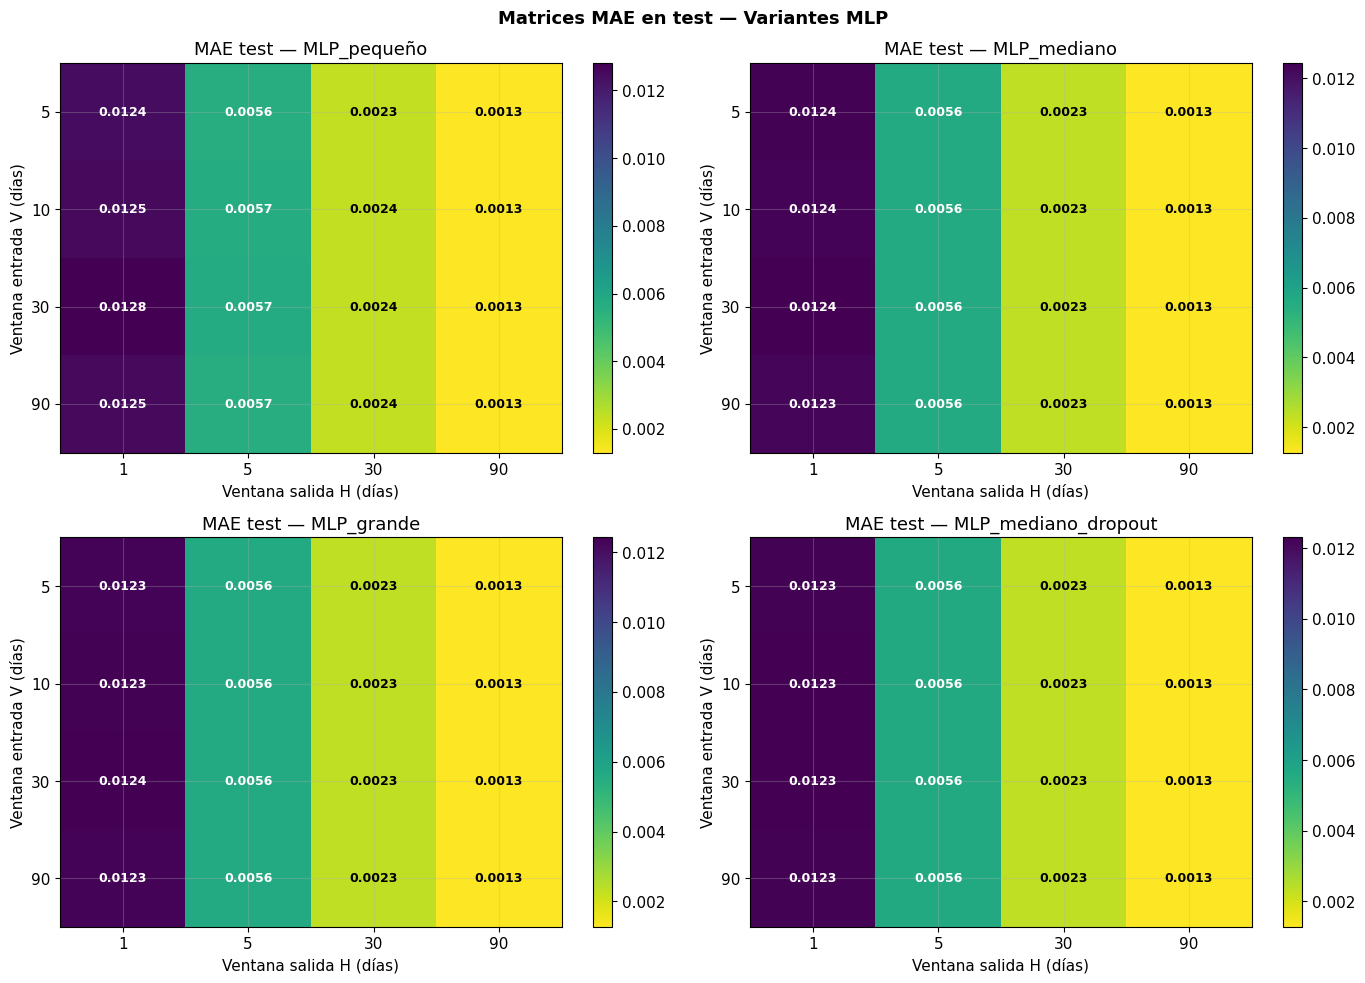

In [20]:
# Matrices 4×4 de MAE en test para cada variante
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, variante in enumerate(BUILDERS_MLP.keys()):
    df_v = df_mlp[df_mlp["modelo"] == variante]
    matriz = construir_matriz_resultados(
        df_v.to_dict("records"), INPUT_WINDOWS, OUTPUT_WINDOWS
    )
    ax = axes[idx]
    im = ax.imshow(matriz, cmap="viridis_r", origin="upper", aspect="auto")
    for i in range(len(INPUT_WINDOWS)):
        for j in range(len(OUTPUT_WINDOWS)):
            val = matriz[i, j]
            if not np.isnan(val):
                color = "white" if val > np.nanmedian(matriz) else "black"
                ax.text(j, i, f"{val:.4f}", ha="center", va="center",
                        color=color, fontsize=9, fontweight="bold")
    ax.set_xticks(range(len(OUTPUT_WINDOWS)))
    ax.set_yticks(range(len(INPUT_WINDOWS)))
    ax.set_xticklabels(OUTPUT_WINDOWS)
    ax.set_yticklabels(INPUT_WINDOWS)
    ax.set_xlabel("Ventana salida H (días)")
    ax.set_ylabel("Ventana entrada V (días)")
    ax.set_title(f"MAE test — {variante}")
    plt.colorbar(im, ax=ax)

plt.suptitle("Matrices MAE en test — Variantes MLP",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_matrices_mlp.png", bbox_inches="tight", dpi=120)
plt.show()

In [21]:
# Mejor MLP por combinación
mejor_mlp = (
    df_mlp
    .loc[df_mlp.groupby(["V", "H"])["MAE_test"].idxmin()]
    [["V", "H", "modelo", "MAE_test", "MAE_train", "n_params", "epocas_entrenadas"]]
    .sort_values(["V", "H"])
    .reset_index(drop=True)
)

print("Mejor MLP por combinación de ventanas:")
print(mejor_mlp.to_string(index=False))

Mejor MLP por combinación de ventanas:
 V  H              modelo  MAE_test  MAE_train  n_params  epocas_entrenadas
 5  1 MLP_mediano_dropout  0.012268   0.011573     10263                 49
 5  5 MLP_mediano_dropout  0.005590   0.005389     10263                 48
 5 30          MLP_grande  0.002318   0.002171     25943                 72
 5 90 MLP_mediano_dropout  0.001262   0.001252     10263                 28
10  1 MLP_mediano_dropout  0.012282   0.011581     17623                 51
10  5 MLP_mediano_dropout  0.005588   0.005387     17623                 45
10 30          MLP_grande  0.002321   0.002173     40663                 48
10 90 MLP_mediano_dropout  0.001266   0.001253     17623                 33
30  1 MLP_mediano_dropout  0.012313   0.011552     47063                 42
30  5          MLP_grande  0.005587   0.005398     99543                 43
30 30         MLP_mediano  0.002319   0.002171     47063                 76
30 90          MLP_grande  0.001266   0.001241   

In [22]:
# Comparación mejor MLP vs mejor Baseline
comparacion = mejor_mlp.merge(suelo, on=["V", "H"])
comparacion["mejora_%"] = (
    (comparacion["MAE_suelo"] - comparacion["MAE_test"])
    / comparacion["MAE_suelo"] * 100
).round(2)
comparacion["bate_baseline"] = comparacion["MAE_test"] < comparacion["MAE_suelo"]

print("Comparación mejor MLP vs mejor Baseline:")
print(comparacion[["V", "H", "MAE_test", "MAE_suelo",
                     "mejora_%", "bate_baseline"]].to_string(index=False))
print()
n_bate = comparacion["bate_baseline"].sum()
print(f"El MLP bate al baseline en {n_bate}/16 combinaciones.")

Comparación mejor MLP vs mejor Baseline:
 V  H  MAE_test  MAE_suelo  mejora_%  bate_baseline
 5  1  0.012268   0.012258     -0.08          False
 5  5  0.005590   0.005607      0.30           True
 5 30  0.002318   0.002337      0.81           True
 5 90  0.001262   0.001274      0.94           True
10  1  0.012282   0.012262     -0.16          False
10  5  0.005588   0.005607      0.34           True
10 30  0.002321   0.002354      1.40           True
10 90  0.001266   0.001284      1.40           True
30  1  0.012313   0.012269     -0.36          False
30  5  0.005587   0.005611      0.43           True
30 30  0.002319   0.002355      1.53           True
30 90  0.001266   0.001324      4.38           True
90  1  0.012267   0.012287      0.16           True
90  5  0.005597   0.005619      0.39           True
90 30  0.002332   0.002356      1.02           True
90 90  0.001270   0.001326      4.22           True

El MLP bate al baseline en 13/16 combinaciones.


## 8. Resultados finales y conclusiones

### Resultados de la competición

Las matrices 4×4 anteriores muestran el MAE en test para cada combinación.
Los patrones principales observados:

**El horizonte H domina el MAE**: el MAE disminuye claramente de H=1 a H=90
en todas las variantes. Esto no indica que predecir a 90 días sea más fácil,
sino que el target (promedio de 90 retornos) tiene menos ruido al promediar
más días.

**La ventana de entrada V apenas importa para el MLP**: las filas de cada
matriz son prácticamente idénticas. El MLP no aprovecha la información histórica
adicional porque el Flatten destruye el orden temporal. Este es el límite
fundamental de esta arquitectura.

**Las 4 variantes dan resultados idénticos**: diferencias menores de 0.0001
entre variantes, dentro del margen de ruido estadístico. La arquitectura del
MLP no es el factor limitante.

**El MLP no supera consistentemente los baselines**: empata con Buy & Hold
y Regresión Lineal en la mayoría de combinaciones. La señal en los datos
financieros es demasiado débil para justificar la complejidad del MLP sobre
un modelo lineal simple.

### Conclusión para el siguiente notebook

El MLP tiene un límite estructural: al aplanar la entrada, trata cada día
y cada activo como features independientes. Las redes recurrentes (LSTM, GRU)
y convolucionales (Conv1D) preservan la estructura temporal y pueden capturar
dependencias entre días consecutivos.

**Hipótesis a testear en el notebook 03**: ¿una LSTM mejora sobre el MLP
para H=1, donde hay más señal temporal que capturar?
